In [2]:
import numpy as np
import cv2
import torch
import os
from patch_detector import PatchDetector


In [8]:
device = 'cuda'

SAC_processor = PatchDetector(3, 1, base_filter=16, device=device, square_sizes=[150, 100, 75, 50, 25], n_patch=1)
SAC_processor.unet.load_state_dict(torch.load("/data/sjh/code/SegmentAndComplete/runs/coco_frcnn/pretrain/checkpoints/CP_epoch1_255.pth", map_location=device))

# load adversarial image
image_0 = cv2.imread("/data/zjh/code/defense/SegmentAndComplete/adv_test/advimg/11.png")
image_0 = cv2.cvtColor(image_0, cv2.COLOR_BGR2RGB) 

image = np.stack([image_0], axis=0).astype(np.float32)/255.0 

image=image.transpose(0,3,1,2)
image1=torch.tensor(image).to(device).float()
print(image1.device)
print(SAC_processor.device)

x_processed, mask_list, _ = SAC_processor(image1, bpda=True, shape_completion=False)

image_sac = np.asarray(x_processed[0].cpu().detach())
image_sac =image_sac.transpose(1,2,0)


cuda:0
cuda


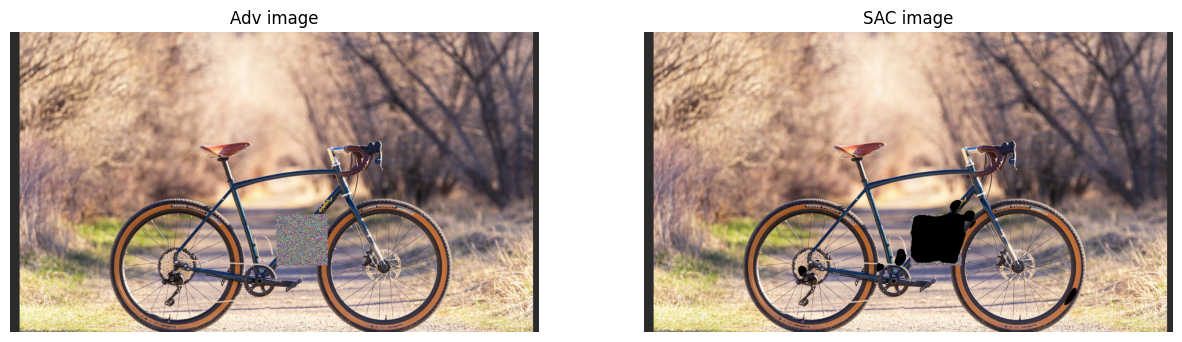

In [9]:
# show images
import matplotlib.pyplot as plt
f, axarr = plt.subplots(1, 2, figsize=(15, 20))
fig0 = axarr[0]
fig1 = axarr[1]
fig0.imshow(image_0)
fig0.axis("off")
fig0.title.set_text('Adv image')
fig1.imshow(image_sac)
fig1.axis("off")
fig1.title.set_text('SAC image')

In [2]:
device = 'cuda'

SAC_processor = PatchDetector(3, 1, base_filter=16, device=device, square_sizes=[150, 100, 75, 50, 25], n_patch=1)
SAC_processor.unet.load_state_dict(torch.load("/data/zjh/code/EvadeDefense/SegmentAndComplete/ckpts/coco_at.pth", map_location=device))


image_path = "/data/zjh/code/eval/results/demo/"
image_list = os.listdir(image_path)

image_path1 = "/data/zjh/code/eval/results/demo_SAC/"

for i in range(len(image_list)):
    # load adversarial image
    image_0 = cv2.imread(image_path + image_list[i])
    image_0 = cv2.cvtColor(image_0, cv2.COLOR_BGR2RGB) 

    image = np.stack([image_0], axis=0).astype(np.float32)/255.0 

    image=image.transpose(0,3,1,2)
    image1=torch.tensor(image).to(device).float()
    x_processed, _, _ = SAC_processor(image1, bpda=True, shape_completion=False)

    image_sac = np.asarray(x_processed[0].cpu().detach())
    image_sac =image_sac.transpose(1,2,0) * 255
    image_sac = np.array(np.clip(image_sac, 0, 255), np.uint8)

    cv2.imwrite(image_path1 + image_list[i], cv2.cvtColor(image_sac, cv2.COLOR_RGB2BGR))